# Adaptive Caliper Selection: Multi-Objective Optimization Framework
## A Complete Simulation Study with Pareto Frontier Analysis

**Authors:** Perkins Watambwa et al. | CeSHHAR Zimbabwe

---

This notebook implements and demonstrates the **Multi-Objective Optimization Framework** for adaptive caliper selection in propensity score matching. The framework addresses the fundamental trade-off between:

1. **Covariate Balance** (minimize bias)
2. **Effective Sample Size** (maximize statistical efficiency)

All outputs (figures, tables, results) are saved to structured directories for reproducibility.

---
## Section 1: Setup and Imports

We begin by importing all necessary libraries and modules from the `src` directory.

In [1]:
# =============================================================================
# SECTION 1: SETUP AND IMPORTS
# =============================================================================

import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import project modules
from config import *
from data_generator import DataGenerator
from matching import PropensityScoreMatcher, compute_balance_statistics, compute_max_abs_smd
from adaptive_caliper import AdaptiveCaliperSelector, run_acs_analysis
from treatment_effect import evaluate_treatment_effect_estimation
from simulation_runner import run_scenario_simulation, summarize_results
from visualization import plot_pareto_frontier, plot_ps_distribution, plot_love_plot, plot_method_comparison_boxplot

# Apply plotting parameters
plt.rcParams.update(PLT_PARAMS)

# Ensure output directories exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('=' * 70)
print('ADAPTIVE CALIPER SELECTION: MULTI-OBJECTIVE OPTIMIZATION FRAMEWORK')
print('=' * 70)
print(f'Output directories:')
print(f'  Figures: {FIGURES_DIR}')
print(f'  Tables:  {TABLES_DIR}')
print(f'  Results: {RESULTS_DIR}')
print('\nSetup complete!')

ADAPTIVE CALIPER SELECTION: MULTI-OBJECTIVE OPTIMIZATION FRAMEWORK
Output directories:
  Figures: C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\figures
  Tables:  C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\tables
  Results: C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\results

Setup complete!


---
## Section 2: Mathematical Formulation

### 2.1 The Two Competing Objectives

We formalize caliper selection as a **multi-objective optimization problem**:

**Objective 1 - Covariate Balance (Minimize):**
$$B(c) = \max_{k=1,\ldots,p} |\text{SMD}_k(c)|$$

**Objective 2 - Sample Retention (Maximize):**
$$R(c) = \frac{m(c)}{\min(n_1, n_0)}$$

These objectives are **generally conflicting**: decreasing $c$ improves balance but reduces retention.

---
## Section 3: Generate Synthetic Data

In [2]:
# =============================================================================
# SECTION 3: GENERATE SYNTHETIC DATA
# =============================================================================

np.random.seed(RANDOM_SEED)
generator = DataGenerator(seed=RANDOM_SEED)

df = generator.generate_dataset(
    n=1000, 
    treatment_prevalence=0.5, 
    overlap_level=0.6,
    confounding_strength=1.0
)

df['e_hat'] = generator.estimate_propensity_scores(df)
covariate_cols = [f'X{i+1}' for i in range(N_TOTAL_COVARIATES)]

n_treated = int(df['Z'].sum())
n_control = int((1 - df['Z']).sum())
ps_corr = np.corrcoef(df['e_true'], df['e_hat'])[0, 1]

print('=' * 60)
print('DATA GENERATION SUMMARY')
print('=' * 60)
print(f'Total sample size:     {len(df)}')
print(f'Treated units:         {n_treated}')
print(f'Control units:         {n_control}')
print(f'Max potential matches: {min(n_treated, n_control)}')
print(f'PS correlation:        {ps_corr:.4f}')

DATA GENERATION SUMMARY
Total sample size:     1000
Treated units:         495
Control units:         505
Max potential matches: 495
PS correlation:        0.9805


### 3.1 Propensity Score Distribution

Saved: C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\figures\fig1_ps_distribution.png


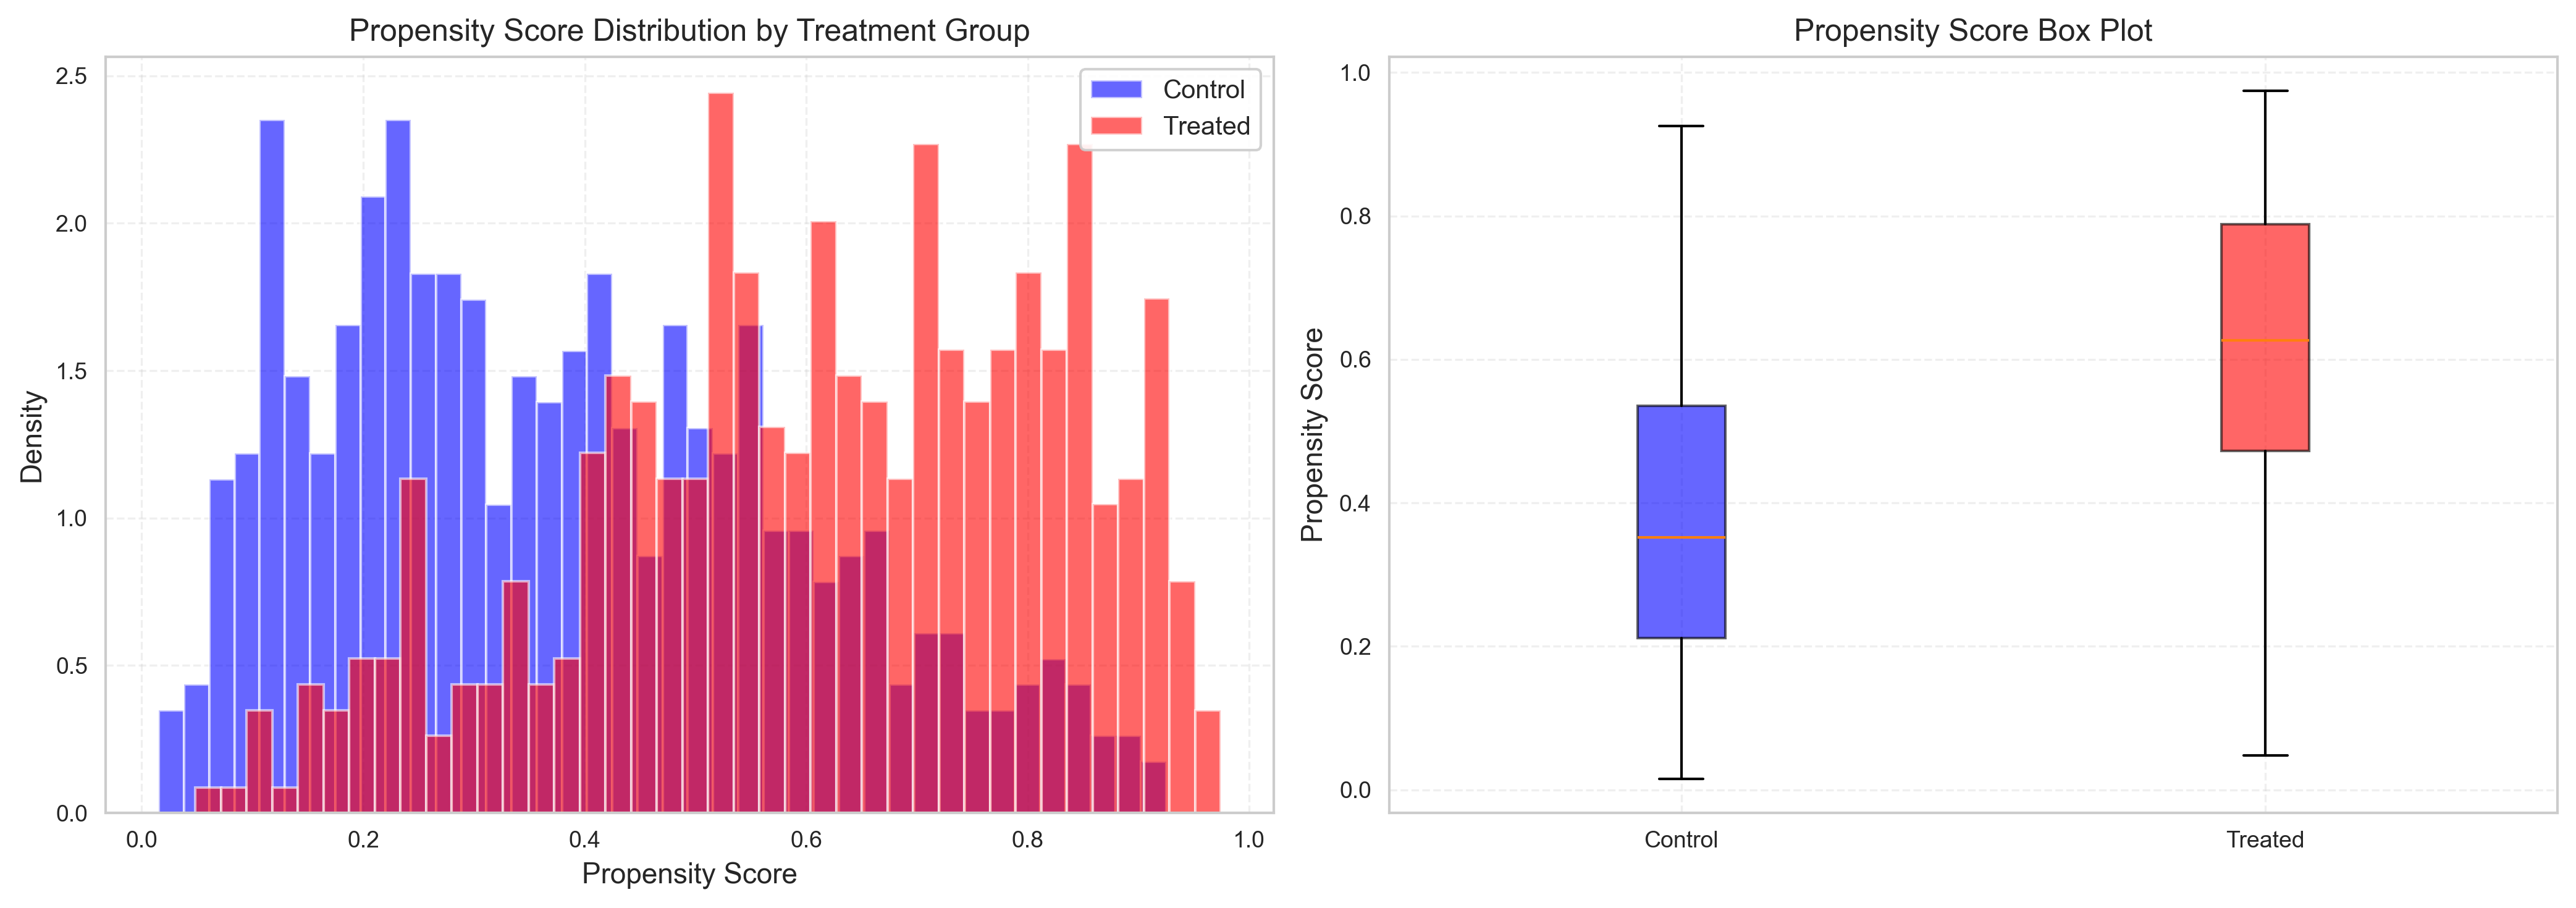

In [3]:
# =============================================================================
# FIGURE 1: PROPENSITY SCORE DISTRIBUTION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(df[df['Z']==0]['e_hat'], bins=40, alpha=0.6, color='blue', label='Control', density=True)
ax1.hist(df[df['Z']==1]['e_hat'], bins=40, alpha=0.6, color='red', label='Treated', density=True)
ax1.set_xlabel('Propensity Score', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('Propensity Score Distribution by Treatment Group', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
data_to_plot = [df[df['Z']==0]['e_hat'], df[df['Z']==1]['e_hat']]
bp = ax2.boxplot(data_to_plot, labels=['Control', 'Treated'], patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('red')
bp['boxes'][1].set_alpha(0.6)
ax2.set_ylabel('Propensity Score', fontsize=11)
ax2.set_title('Propensity Score Box Plot', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig1_ps_distribution.png', dpi=FIGURE_DPI, bbox_inches='tight')
print(f'Saved: {FIGURES_DIR / "fig1_ps_distribution.png"}')
plt.show()

---
## Section 4: Pareto Frontier Characterization

A caliper value $c^*$ is **Pareto optimal** if no other caliper can improve one objective without worsening the other.

In [4]:
# =============================================================================
# SECTION 4: PARETO FRONTIER CHARACTERIZATION
# =============================================================================

selector = AdaptiveCaliperSelector(seed=RANDOM_SEED)
selector.fit(df, covariate_cols=covariate_cols)

all_results_df = selector.get_all_results_dataframe()
pareto_df = selector.get_frontier_dataframe()

print('=' * 70)
print('TABLE 1: ALL CALIPER EVALUATIONS')
print('=' * 70)
print(all_results_df.to_string(index=False))

all_results_df.to_csv(TABLES_DIR / 'table1_all_caliper_evaluations.csv', index=False)
print(f'\nSaved: {TABLES_DIR / "table1_all_caliper_evaluations.csv"}')

TABLE 1: ALL CALIPER EVALUATIONS
 caliper  caliper_absolute  max_abs_smd  retention  n_matched  is_pareto_optimal
    0.05          0.061320     0.070602   0.571717        283              False
    0.10          0.122640     0.061779   0.587879        291              False
    0.15          0.183961     0.048042   0.587879        291               True
    0.20          0.245281     0.048042   0.587879        291              False
    0.25          0.306601     0.068183   0.591919        293              False
    0.30          0.367921     0.061149   0.593939        294              False
    0.35          0.429241     0.060532   0.600000        297               True
    0.40          0.490561     0.086318   0.608081        301              False
    0.45          0.551882     0.071825   0.618182        306               True
    0.50          0.613202     0.077855   0.622222        308               True
    0.60          0.735842     0.081701   0.642424        318               

In [5]:
# =============================================================================
# TABLE 2: PARETO FRONTIER
# =============================================================================

print('=' * 70)
print('TABLE 2: PARETO FRONTIER - OPTIMAL TRADE-OFF POINTS')
print('=' * 70)
print(pareto_df.to_string(index=False))

pareto_df.to_csv(TABLES_DIR / 'table2_pareto_frontier.csv', index=False)
print(f'\nSaved: {TABLES_DIR / "table2_pareto_frontier.csv"}')

TABLE 2: PARETO FRONTIER - OPTIMAL TRADE-OFF POINTS
 caliper  caliper_absolute  max_abs_smd  retention  n_matched
    2.00          2.452807     0.344213   0.894949        443
    1.50          1.839605     0.259461   0.822222        407
    1.00          1.226403     0.133116   0.729293        361
    0.90          1.103763     0.119751   0.709091        351
    0.80          0.981123     0.105921   0.686869        340
    0.70          0.858482     0.097232   0.664646        329
    0.60          0.735842     0.081701   0.642424        318
    0.50          0.613202     0.077855   0.622222        308
    0.45          0.551882     0.071825   0.618182        306
    0.35          0.429241     0.060532   0.600000        297
    0.15          0.183961     0.048042   0.587879        291

Saved: C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\tables\table2_pareto_frontier.csv


Saved: C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\figures\fig2_pareto_frontier.png


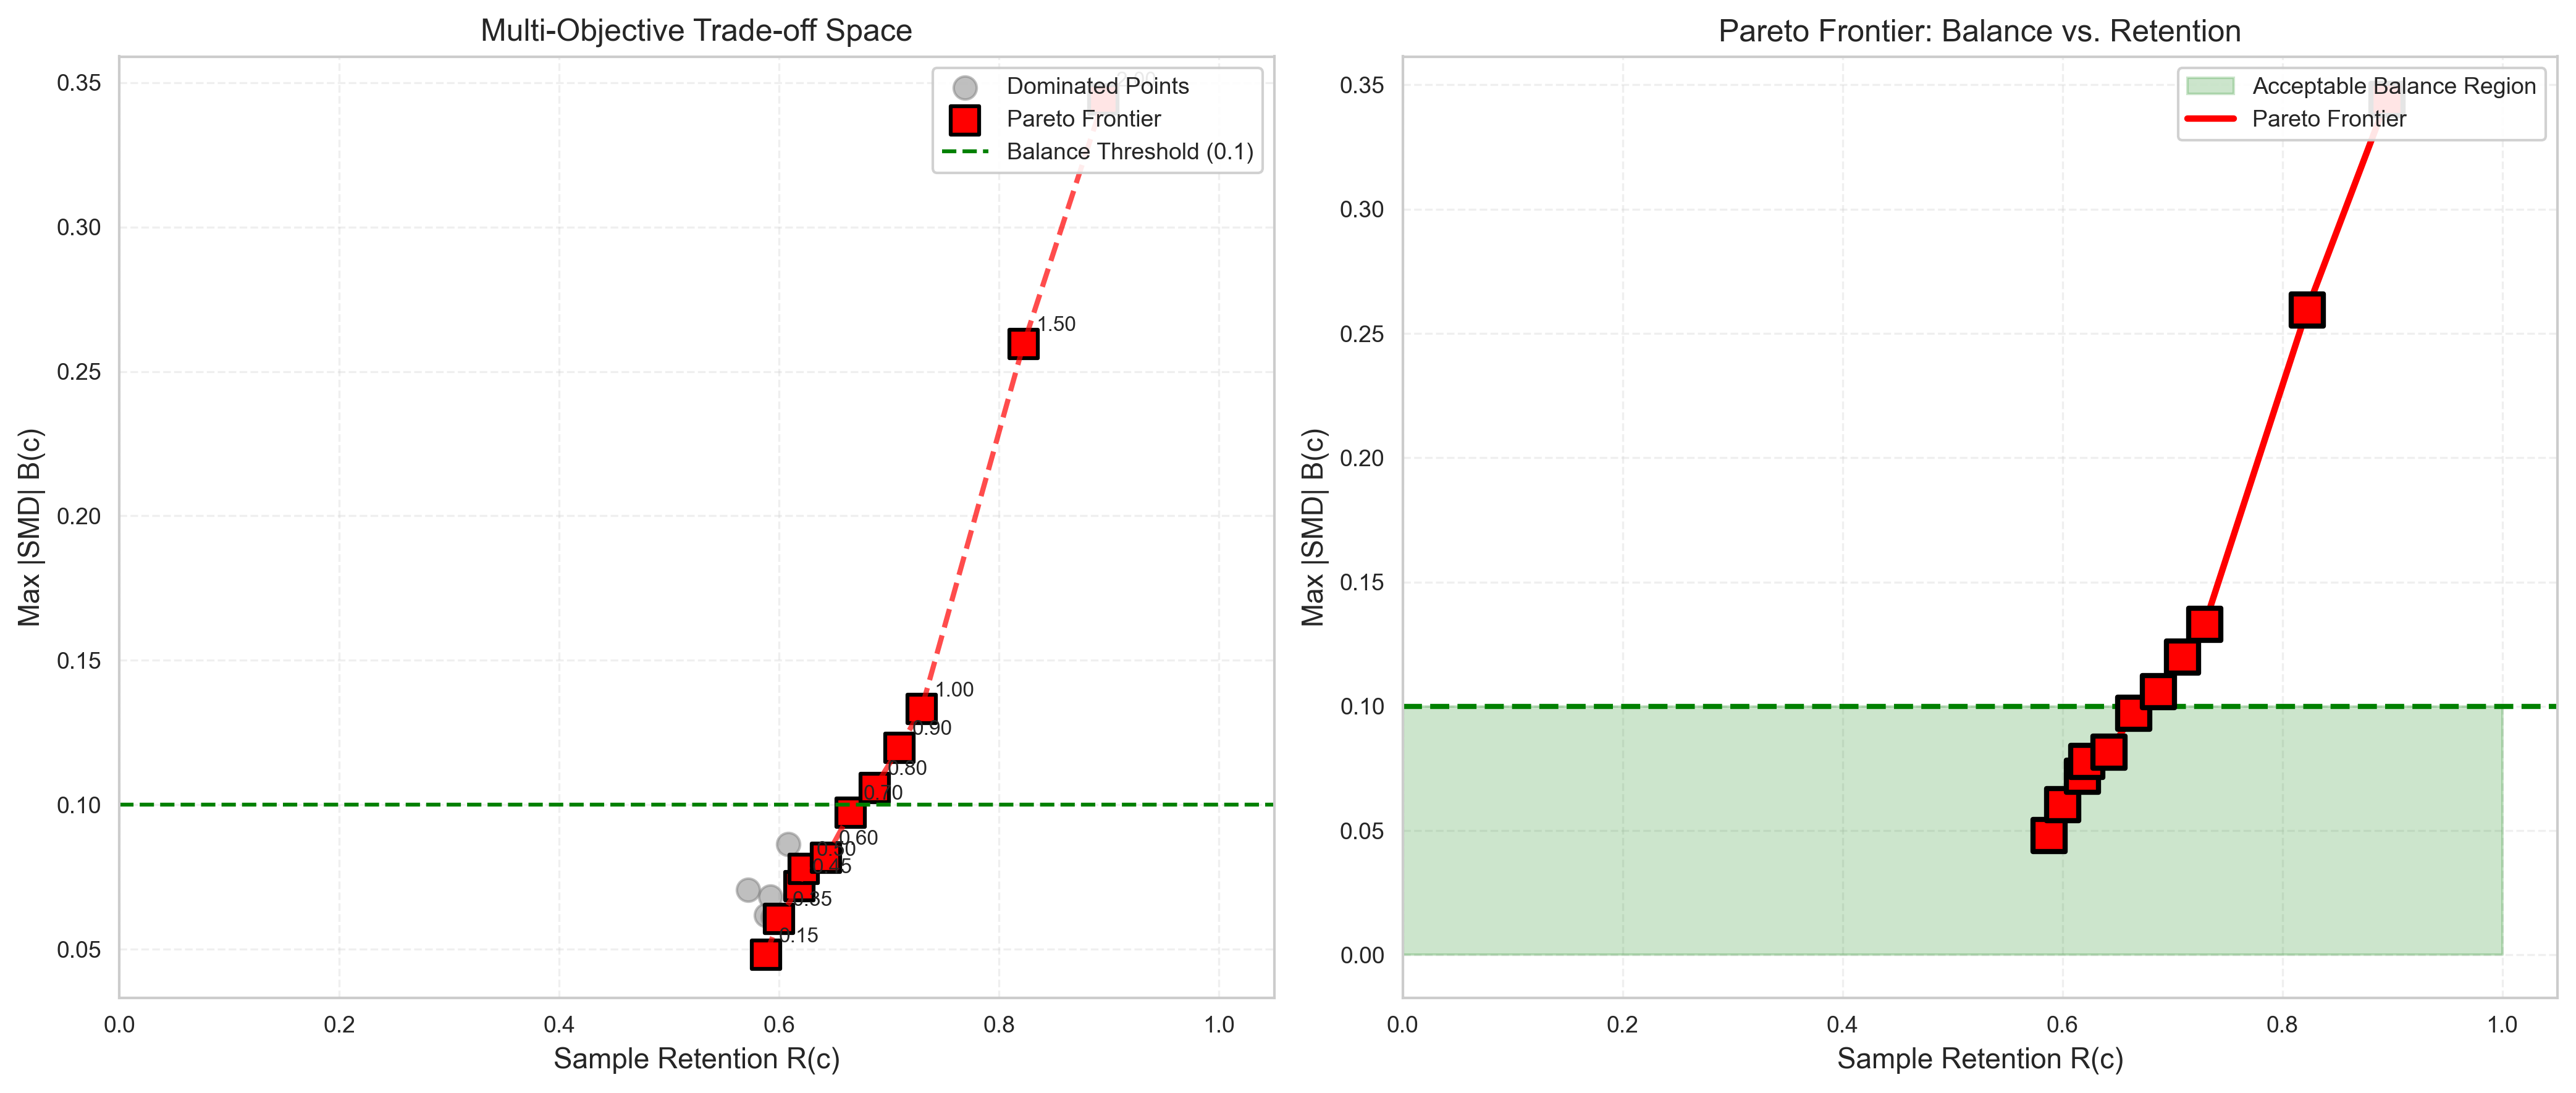

In [6]:
# =============================================================================
# FIGURE 2: PARETO FRONTIER VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
non_pareto = all_results_df[~all_results_df['is_pareto_optimal']]
pareto = all_results_df[all_results_df['is_pareto_optimal']]

ax1.scatter(non_pareto['retention'], non_pareto['max_abs_smd'], 
            c='gray', alpha=0.5, s=80, label='Dominated Points', marker='o')
ax1.scatter(pareto['retention'], pareto['max_abs_smd'], 
            c='red', s=120, label='Pareto Frontier', marker='s', edgecolors='black', linewidths=1.5)

pareto_sorted = pareto.sort_values('retention')
ax1.plot(pareto_sorted['retention'], pareto_sorted['max_abs_smd'], 'r--', linewidth=2, alpha=0.7)

for _, row in pareto.iterrows():
    ax1.annotate(f'{row["caliper"]:.2f}', 
                 (row['retention'], row['max_abs_smd']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)

ax1.axhline(BALANCE_THRESHOLD, color='green', linestyle='--', linewidth=1.5, 
            label=f'Balance Threshold ({BALANCE_THRESHOLD})')
ax1.set_xlabel('Sample Retention R(c)', fontsize=11)
ax1.set_ylabel('Max |SMD| B(c)', fontsize=11)
ax1.set_title('Multi-Objective Trade-off Space', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1.05)

ax2 = axes[1]
ax2.fill_between([0, 1], [0, 0], [BALANCE_THRESHOLD, BALANCE_THRESHOLD], 
                  alpha=0.2, color='green', label='Acceptable Balance Region')
ax2.scatter(pareto['retention'], pareto['max_abs_smd'], 
            c='red', s=150, marker='s', edgecolors='black', linewidths=2, zorder=5)
ax2.plot(pareto_sorted['retention'], pareto_sorted['max_abs_smd'], 'r-', linewidth=2.5, label='Pareto Frontier')
ax2.axhline(BALANCE_THRESHOLD, color='green', linestyle='--', linewidth=2)
ax2.set_xlabel('Sample Retention R(c)', fontsize=11)
ax2.set_ylabel('Max |SMD| B(c)', fontsize=11)
ax2.set_title('Pareto Frontier: Balance vs. Retention', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1.05)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig2_pareto_frontier.png', dpi=FIGURE_DPI, bbox_inches='tight')
print(f'Saved: {FIGURES_DIR / "fig2_pareto_frontier.png"}')
plt.show()

---
## Section 5: Adaptive Caliper Selection Criteria

Three criteria for selecting optimal caliper:
1. **Balance-Constrained**: Largest caliper meeting balance threshold
2. **Knee-Point**: Maximum curvature on Pareto frontier
3. **Weighted**: Minimize weighted combination of objectives

In [7]:
# =============================================================================
# SECTION 5: OPTIMAL CALIPER SELECTION
# =============================================================================

optimal_results = {}
for criterion in ['balance', 'knee', 'weighted']:
    optimal_results[criterion] = selector.select_optimal(criterion)

criteria_summary = []
for criterion, result in optimal_results.items():
    criteria_summary.append({
        'Criterion': f'ACS-{criterion.capitalize()}',
        'Optimal Caliper (SD)': result.optimal_caliper,
        'Max |SMD|': result.balance_at_optimal,
        'Retention': result.retention_at_optimal,
        'N Matched Pairs': result.n_matched_at_optimal,
        'Meets Threshold': 'Yes' if result.balance_at_optimal <= BALANCE_THRESHOLD else 'No'
    })

criteria_df = pd.DataFrame(criteria_summary)

print('=' * 80)
print('TABLE 3: OPTIMAL CALIPERS BY CRITERION')
print('=' * 80)
print(f'Balance Threshold: {BALANCE_THRESHOLD}')
print(f'Lambda (weighted): {LAMBDA_WEIGHTED}\n')
print(criteria_df.to_string(index=False))

criteria_df.to_csv(TABLES_DIR / 'table3_optimal_calipers_by_criterion.csv', index=False)
print(f'\nSaved: {TABLES_DIR / "table3_optimal_calipers_by_criterion.csv"}')

TABLE 3: OPTIMAL CALIPERS BY CRITERION
Balance Threshold: 0.1
Lambda (weighted): 0.5

   Criterion  Optimal Caliper (SD)  Max |SMD|  Retention  N Matched Pairs Meets Threshold
 ACS-Balance                   0.7   0.097232   0.664646              329             Yes
    ACS-Knee                   0.5   0.077855   0.622222              308             Yes
ACS-Weighted                   1.0   0.133116   0.729293              361              No

Saved: C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\tables\table3_optimal_calipers_by_criterion.csv


Saved: C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\figures\fig3_optimal_caliper_selection.png


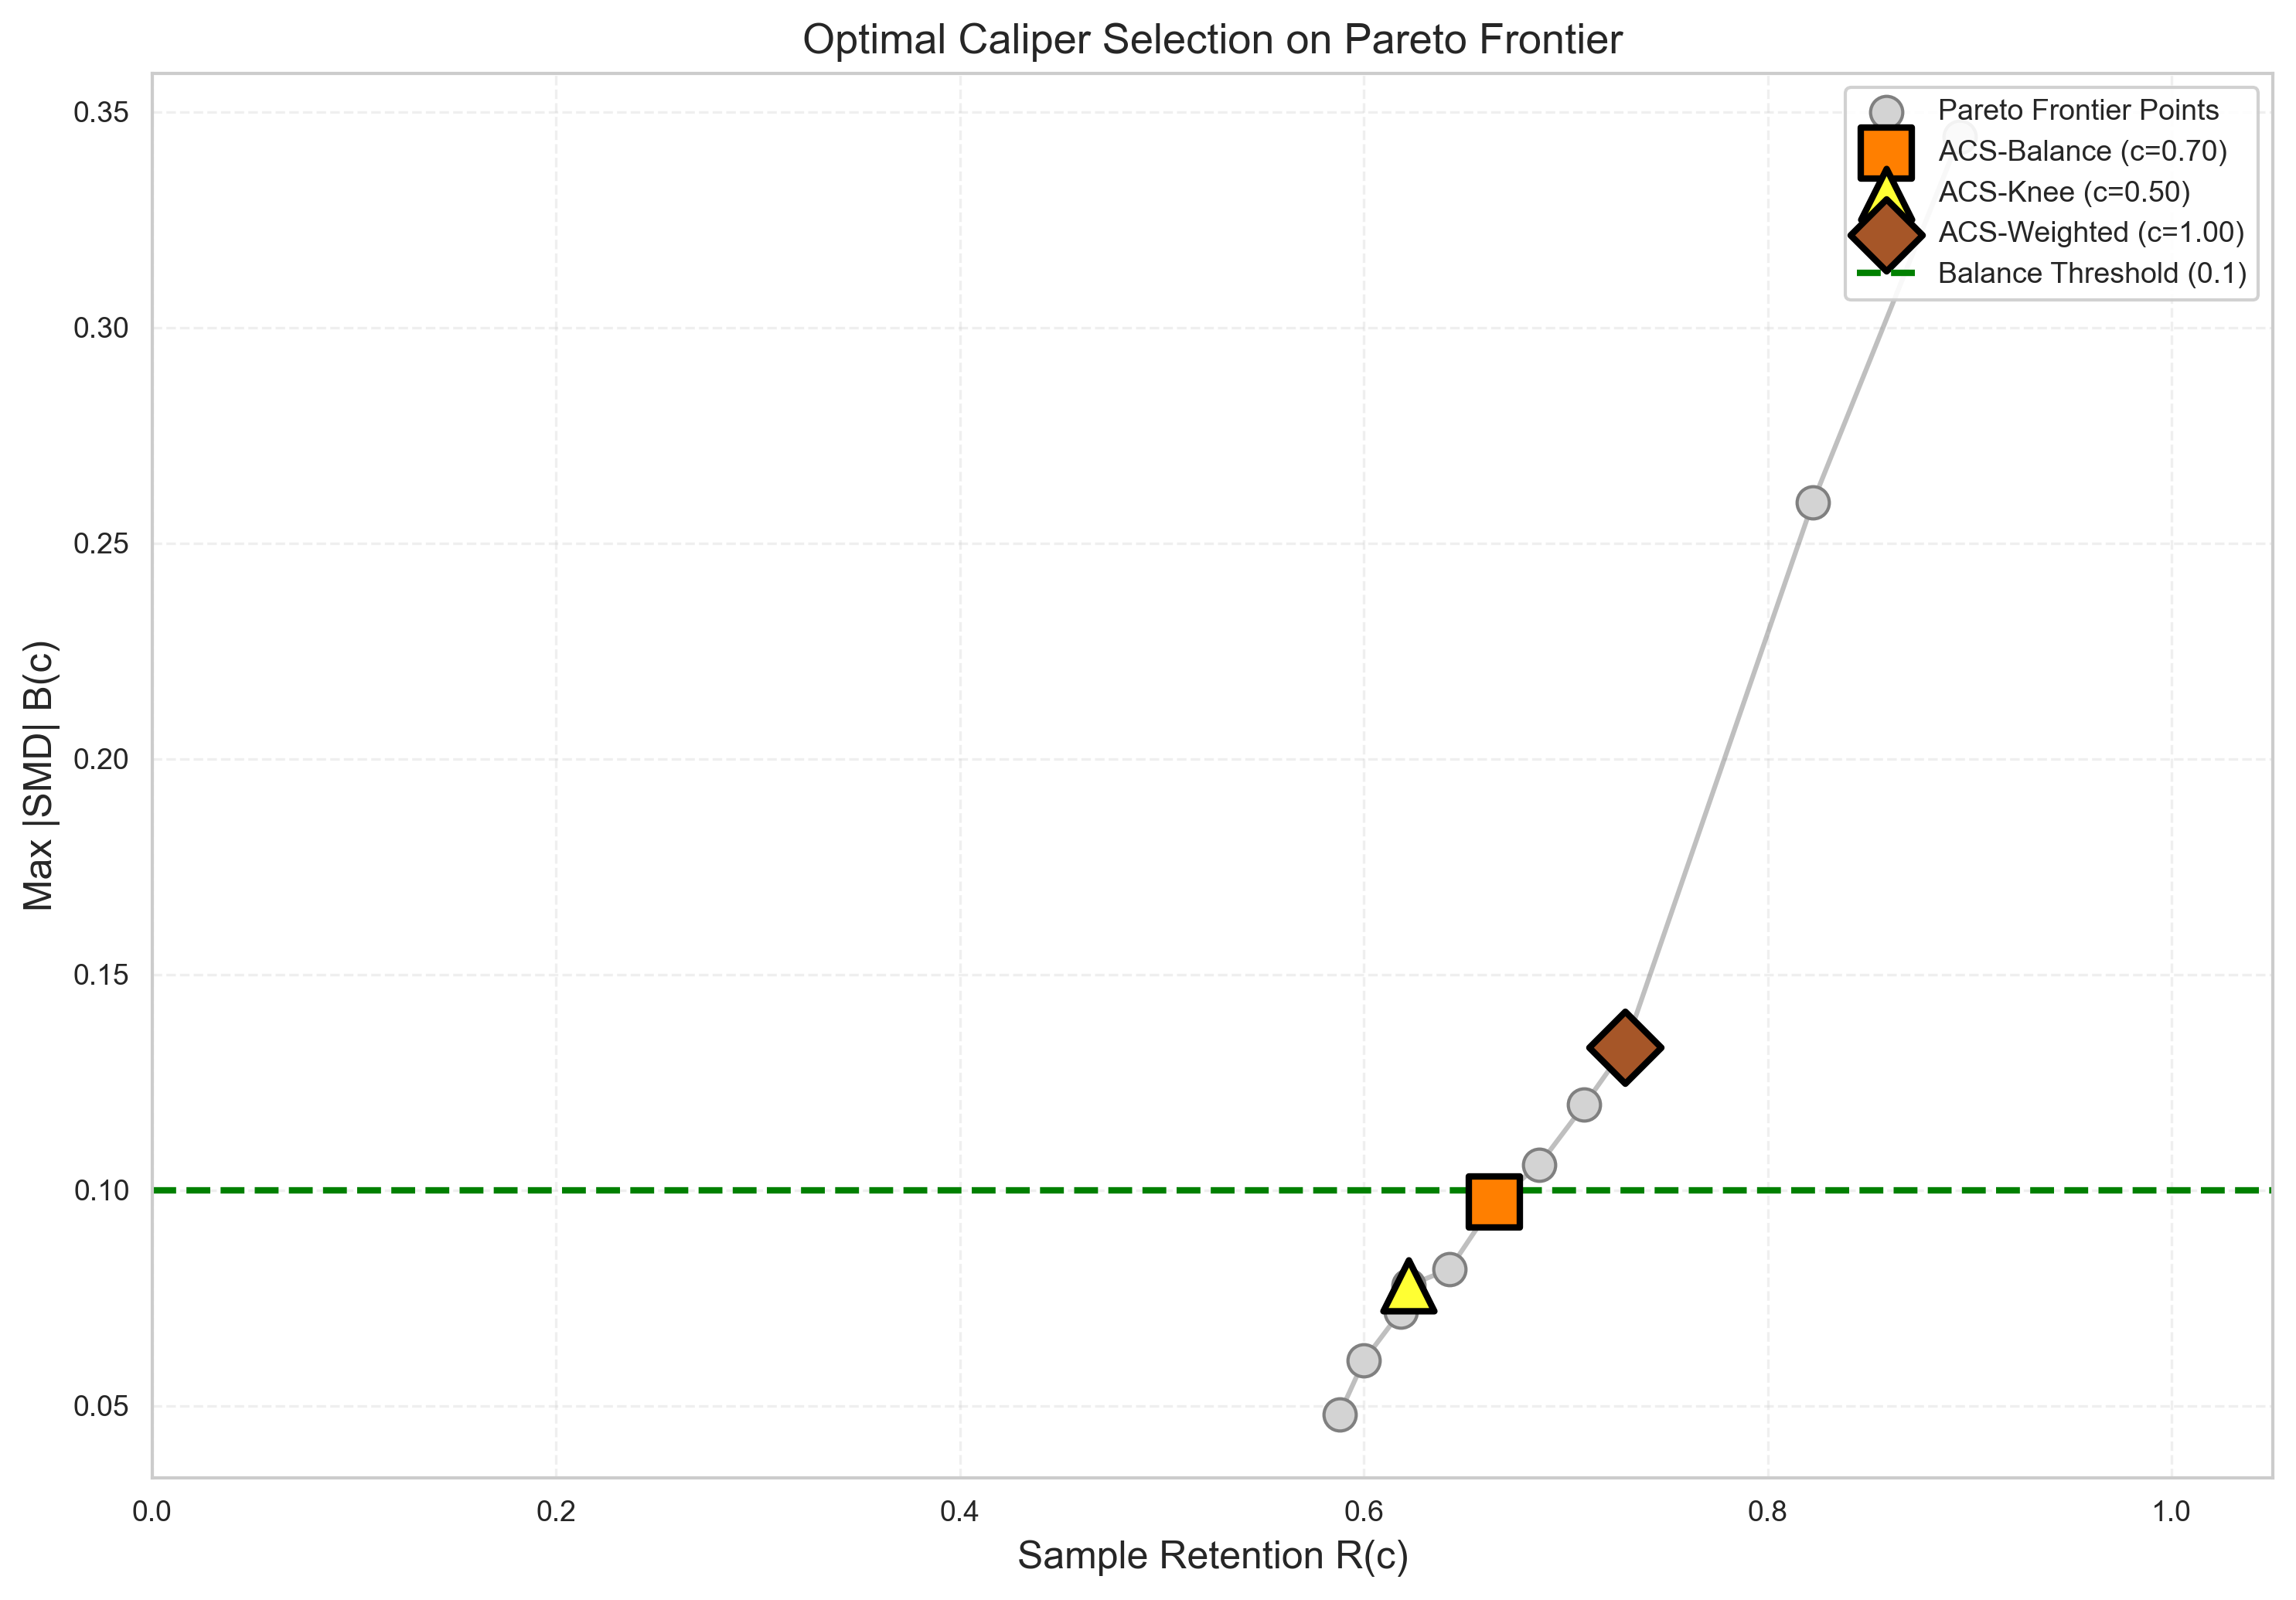

In [8]:
# =============================================================================
# FIGURE 3: OPTIMAL CALIPER SELECTION ON PARETO FRONTIER
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(pareto['retention'], pareto['max_abs_smd'], 
           c='lightgray', s=100, marker='o', edgecolors='gray', linewidths=1, 
           label='Pareto Frontier Points', zorder=2)
ax.plot(pareto_sorted['retention'], pareto_sorted['max_abs_smd'], 
        'gray', linewidth=1.5, alpha=0.5, zorder=1)

colors = {'balance': '#FF7F00', 'knee': '#FFFF33', 'weighted': '#A65628'}
markers = {'balance': 's', 'knee': '^', 'weighted': 'D'}

for criterion, result in optimal_results.items():
    ax.scatter(result.retention_at_optimal, result.balance_at_optimal,
               c=colors[criterion], s=250, marker=markers[criterion],
               edgecolors='black', linewidths=2, zorder=5,
               label=f'ACS-{criterion.capitalize()} (c={result.optimal_caliper:.2f})')

ax.axhline(BALANCE_THRESHOLD, color='green', linestyle='--', linewidth=2, 
           label=f'Balance Threshold ({BALANCE_THRESHOLD})')

ax.set_xlabel('Sample Retention R(c)', fontsize=12)
ax.set_ylabel('Max |SMD| B(c)', fontsize=12)
ax.set_title('Optimal Caliper Selection on Pareto Frontier', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.05)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig3_optimal_caliper_selection.png', dpi=FIGURE_DPI, bbox_inches='tight')
print(f'Saved: {FIGURES_DIR / "fig3_optimal_caliper_selection.png"}')
plt.show()

---
## Section 6: Balance Diagnostics

In [9]:
# =============================================================================
# SECTION 6: BALANCE DIAGNOSTICS
# =============================================================================

optimal_caliper = optimal_results['balance'].optimal_caliper

matcher = PropensityScoreMatcher(caliper=optimal_caliper, seed=RANDOM_SEED)
matcher.fit(df['e_hat'].values, df['Z'].values)
matched_df = matcher.get_matched_data(df)

balance_before = compute_balance_statistics(df, covariate_cols)
balance_after = compute_balance_statistics(matched_df, covariate_cols)

balance_comparison = pd.DataFrame({
    'Covariate': covariate_cols,
    'SMD Before': balance_before['smd'].values,
    '|SMD| Before': balance_before['abs_smd'].values,
    'SMD After': balance_after['smd'].values,
    '|SMD| After': balance_after['abs_smd'].values,
    'Improvement (%)': ((balance_before['abs_smd'].values - balance_after['abs_smd'].values) / 
                        balance_before['abs_smd'].values * 100)
})

print('=' * 80)
print('TABLE 4: COVARIATE BALANCE - BEFORE vs. AFTER MATCHING')
print('=' * 80)
print(f'Caliper: {optimal_caliper:.3f} SD')
print(f'Matched Pairs: {matcher.n_matched_}')
print(f'Retention: {matcher.n_matched_ / min(n_treated, n_control):.1%}\n')
print(balance_comparison.round(4).to_string(index=False))

balance_comparison.to_csv(TABLES_DIR / 'table4_balance_comparison.csv', index=False)
print(f'\nSaved: {TABLES_DIR / "table4_balance_comparison.csv"}')

TABLE 4: COVARIATE BALANCE - BEFORE vs. AFTER MATCHING
Caliper: 0.700 SD
Matched Pairs: 329
Retention: 66.5%

Covariate  SMD Before  |SMD| Before  SMD After  |SMD| After  Improvement (%)
       X1      0.5083        0.5083     0.0891       0.0891          82.4778
       X2      0.4573        0.4573     0.0532       0.0532          88.3645
       X3      0.4495        0.4495     0.0280       0.0280          93.7811
       X4      0.3403        0.3403     0.0729       0.0729          78.5820
       X5      0.1757        0.1757     0.0972       0.0972          44.6695
       X6      0.3655        0.3655     0.0608       0.0608          83.3740

Saved: C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\tables\table4_balance_comparison.csv


Saved: C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\figures\fig4_love_plot.png


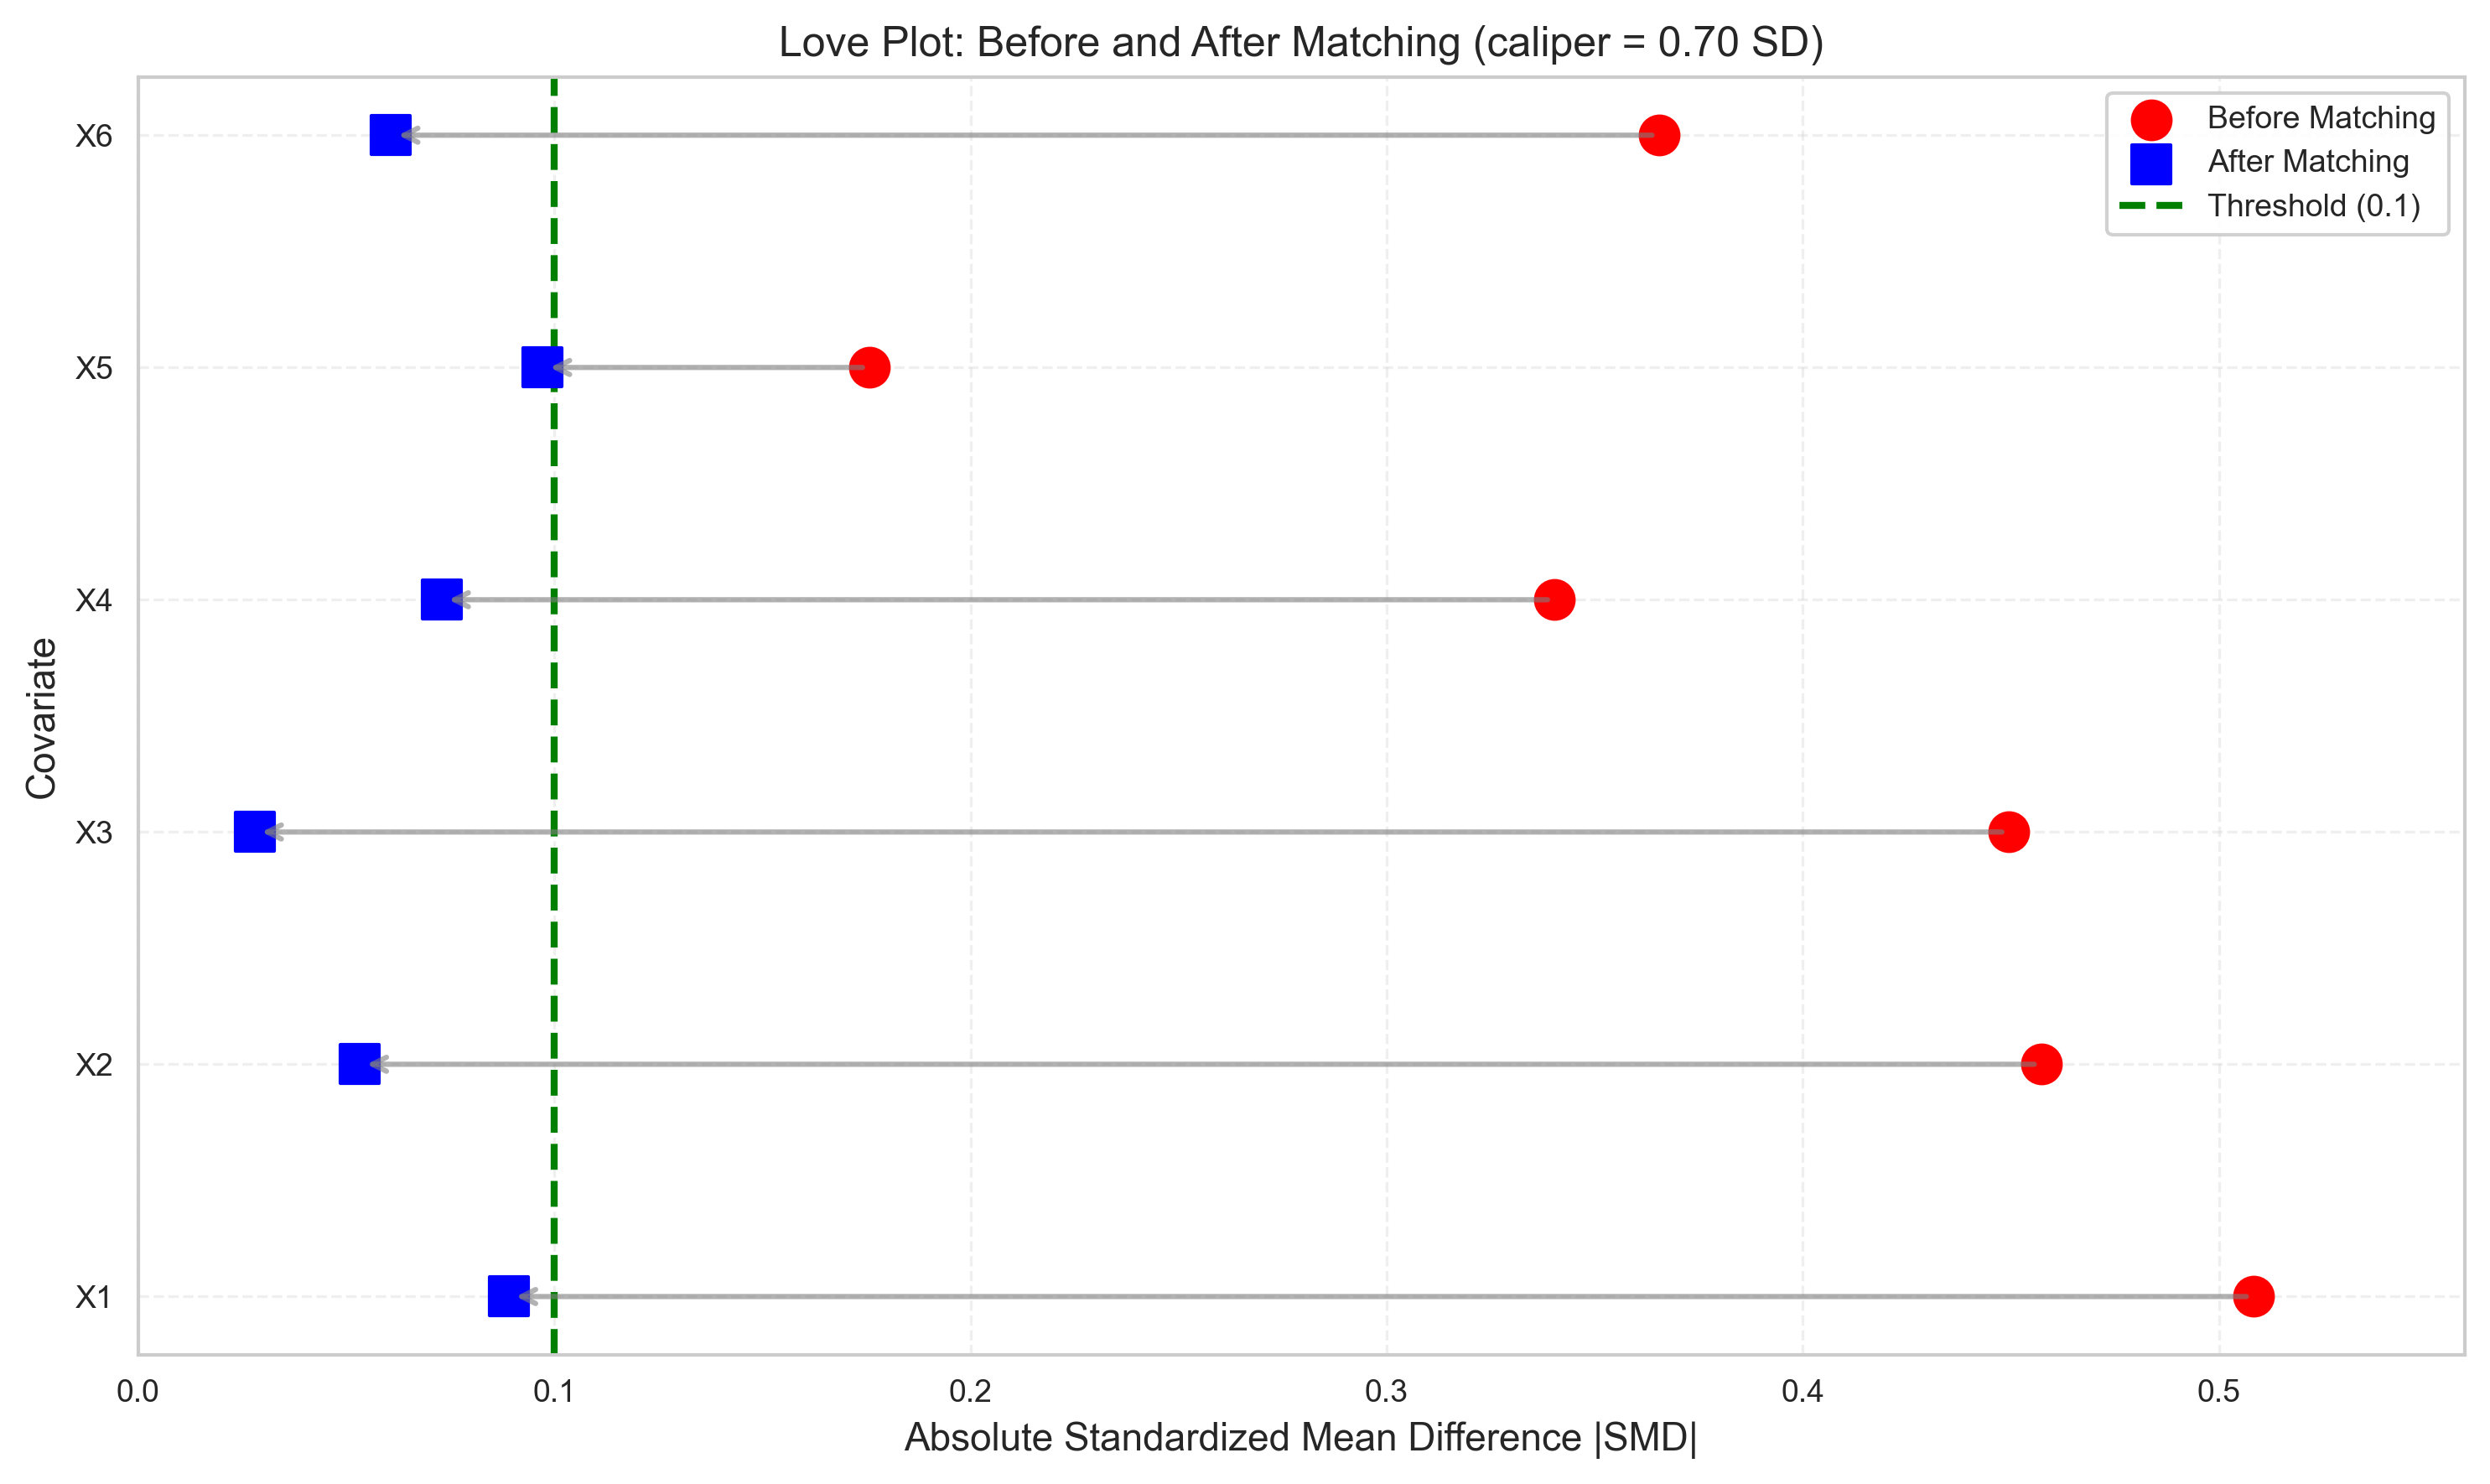

In [10]:
# =============================================================================
# FIGURE 4: LOVE PLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(covariate_cols))

ax.scatter(balance_before['abs_smd'], y_pos, c='red', s=120, marker='o', 
           label='Before Matching', zorder=3)
ax.scatter(balance_after['abs_smd'], y_pos, c='blue', s=120, marker='s', 
           label='After Matching', zorder=3)

for i in range(len(y_pos)):
    ax.annotate('', xy=(balance_after['abs_smd'].iloc[i], y_pos[i]),
                xytext=(balance_before['abs_smd'].iloc[i], y_pos[i]),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, alpha=0.6))

ax.axvline(BALANCE_THRESHOLD, color='green', linestyle='--', linewidth=2, 
           label=f'Threshold ({BALANCE_THRESHOLD})')

ax.set_yticks(y_pos)
ax.set_yticklabels(covariate_cols)
ax.set_xlabel('Absolute Standardized Mean Difference |SMD|', fontsize=11)
ax.set_ylabel('Covariate', fontsize=11)
ax.set_title(f'Love Plot: Before and After Matching (caliper = {optimal_caliper:.2f} SD)', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(0, max(balance_before['abs_smd'].max(), 0.3) * 1.1)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4_love_plot.png', dpi=FIGURE_DPI, bbox_inches='tight')
print(f'Saved: {FIGURES_DIR / "fig4_love_plot.png"}')
plt.show()

---
## Section 7: Treatment Effect Estimation

In [11]:
# =============================================================================
# SECTION 7: TREATMENT EFFECT ESTIMATION
# =============================================================================

te_results = []

for criterion, result in optimal_results.items():
    m = PropensityScoreMatcher(caliper=result.optimal_caliper, seed=RANDOM_SEED)
    m.fit(df['e_hat'].values, df['Z'].values)
    mdf = m.get_matched_data(df)
    te = evaluate_treatment_effect_estimation(mdf, TRUE_TREATMENT_EFFECT)
    
    te_results.append({
        'Method': f'ACS-{criterion.capitalize()}',
        'Caliper (SD)': result.optimal_caliper,
        'N Matched': m.n_matched_,
        'True ATT': TRUE_TREATMENT_EFFECT,
        'Estimated ATT': te['att'],
        'Bias': te['bias'],
        'Std Error': te['se'],
        '95% CI Lower': te['ci_lower'],
        '95% CI Upper': te['ci_upper'],
        'Coverage': te['coverage']
    })

for name, cal in FIXED_CALIPERS.items():
    m = PropensityScoreMatcher(caliper=cal, seed=RANDOM_SEED)
    m.fit(df['e_hat'].values, df['Z'].values)
    if m.n_matched_ > 0:
        mdf = m.get_matched_data(df)
        te = evaluate_treatment_effect_estimation(mdf, TRUE_TREATMENT_EFFECT)
        te_results.append({
            'Method': name,
            'Caliper (SD)': cal,
            'N Matched': m.n_matched_,
            'True ATT': TRUE_TREATMENT_EFFECT,
            'Estimated ATT': te['att'],
            'Bias': te['bias'],
            'Std Error': te['se'],
            '95% CI Lower': te['ci_lower'],
            '95% CI Upper': te['ci_upper'],
            'Coverage': te['coverage']
        })

te_df = pd.DataFrame(te_results)

print('=' * 90)
print('TABLE 5: TREATMENT EFFECT ESTIMATION')
print('=' * 90)
print(f'True ATT: {TRUE_TREATMENT_EFFECT}\n')
print(te_df.round(4).to_string(index=False))

te_df.to_csv(TABLES_DIR / 'table5_treatment_effect_comparison.csv', index=False)
print(f'\nSaved: {TABLES_DIR / "table5_treatment_effect_comparison.csv"}')

TABLE 5: TREATMENT EFFECT ESTIMATION
True ATT: 0.5

      Method  Caliper (SD)  N Matched  True ATT  Estimated ATT    Bias  Std Error  95% CI Lower  95% CI Upper  Coverage
 ACS-Balance           0.7        329       0.5         0.6068  0.1068     0.1109        0.3886        0.8250       1.0
    ACS-Knee           0.5        308       0.5         0.5207  0.0207     0.1077        0.3088        0.7326       1.0
ACS-Weighted           1.0        361       0.5         0.7581  0.2581     0.1042        0.5532        0.9630       0.0
   Fixed-0.1           0.1        291       0.5         0.4139 -0.0861     0.1127        0.1920        0.6358       1.0
   Fixed-0.2           0.2        291       0.5         0.4324 -0.0676     0.1156        0.2049        0.6598       1.0
   Fixed-0.5           0.5        308       0.5         0.5207  0.0207     0.1077        0.3088        0.7326       1.0

Saved: C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\tables\table5_

Saved: C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\figures\fig5_treatment_effect_estimates.png


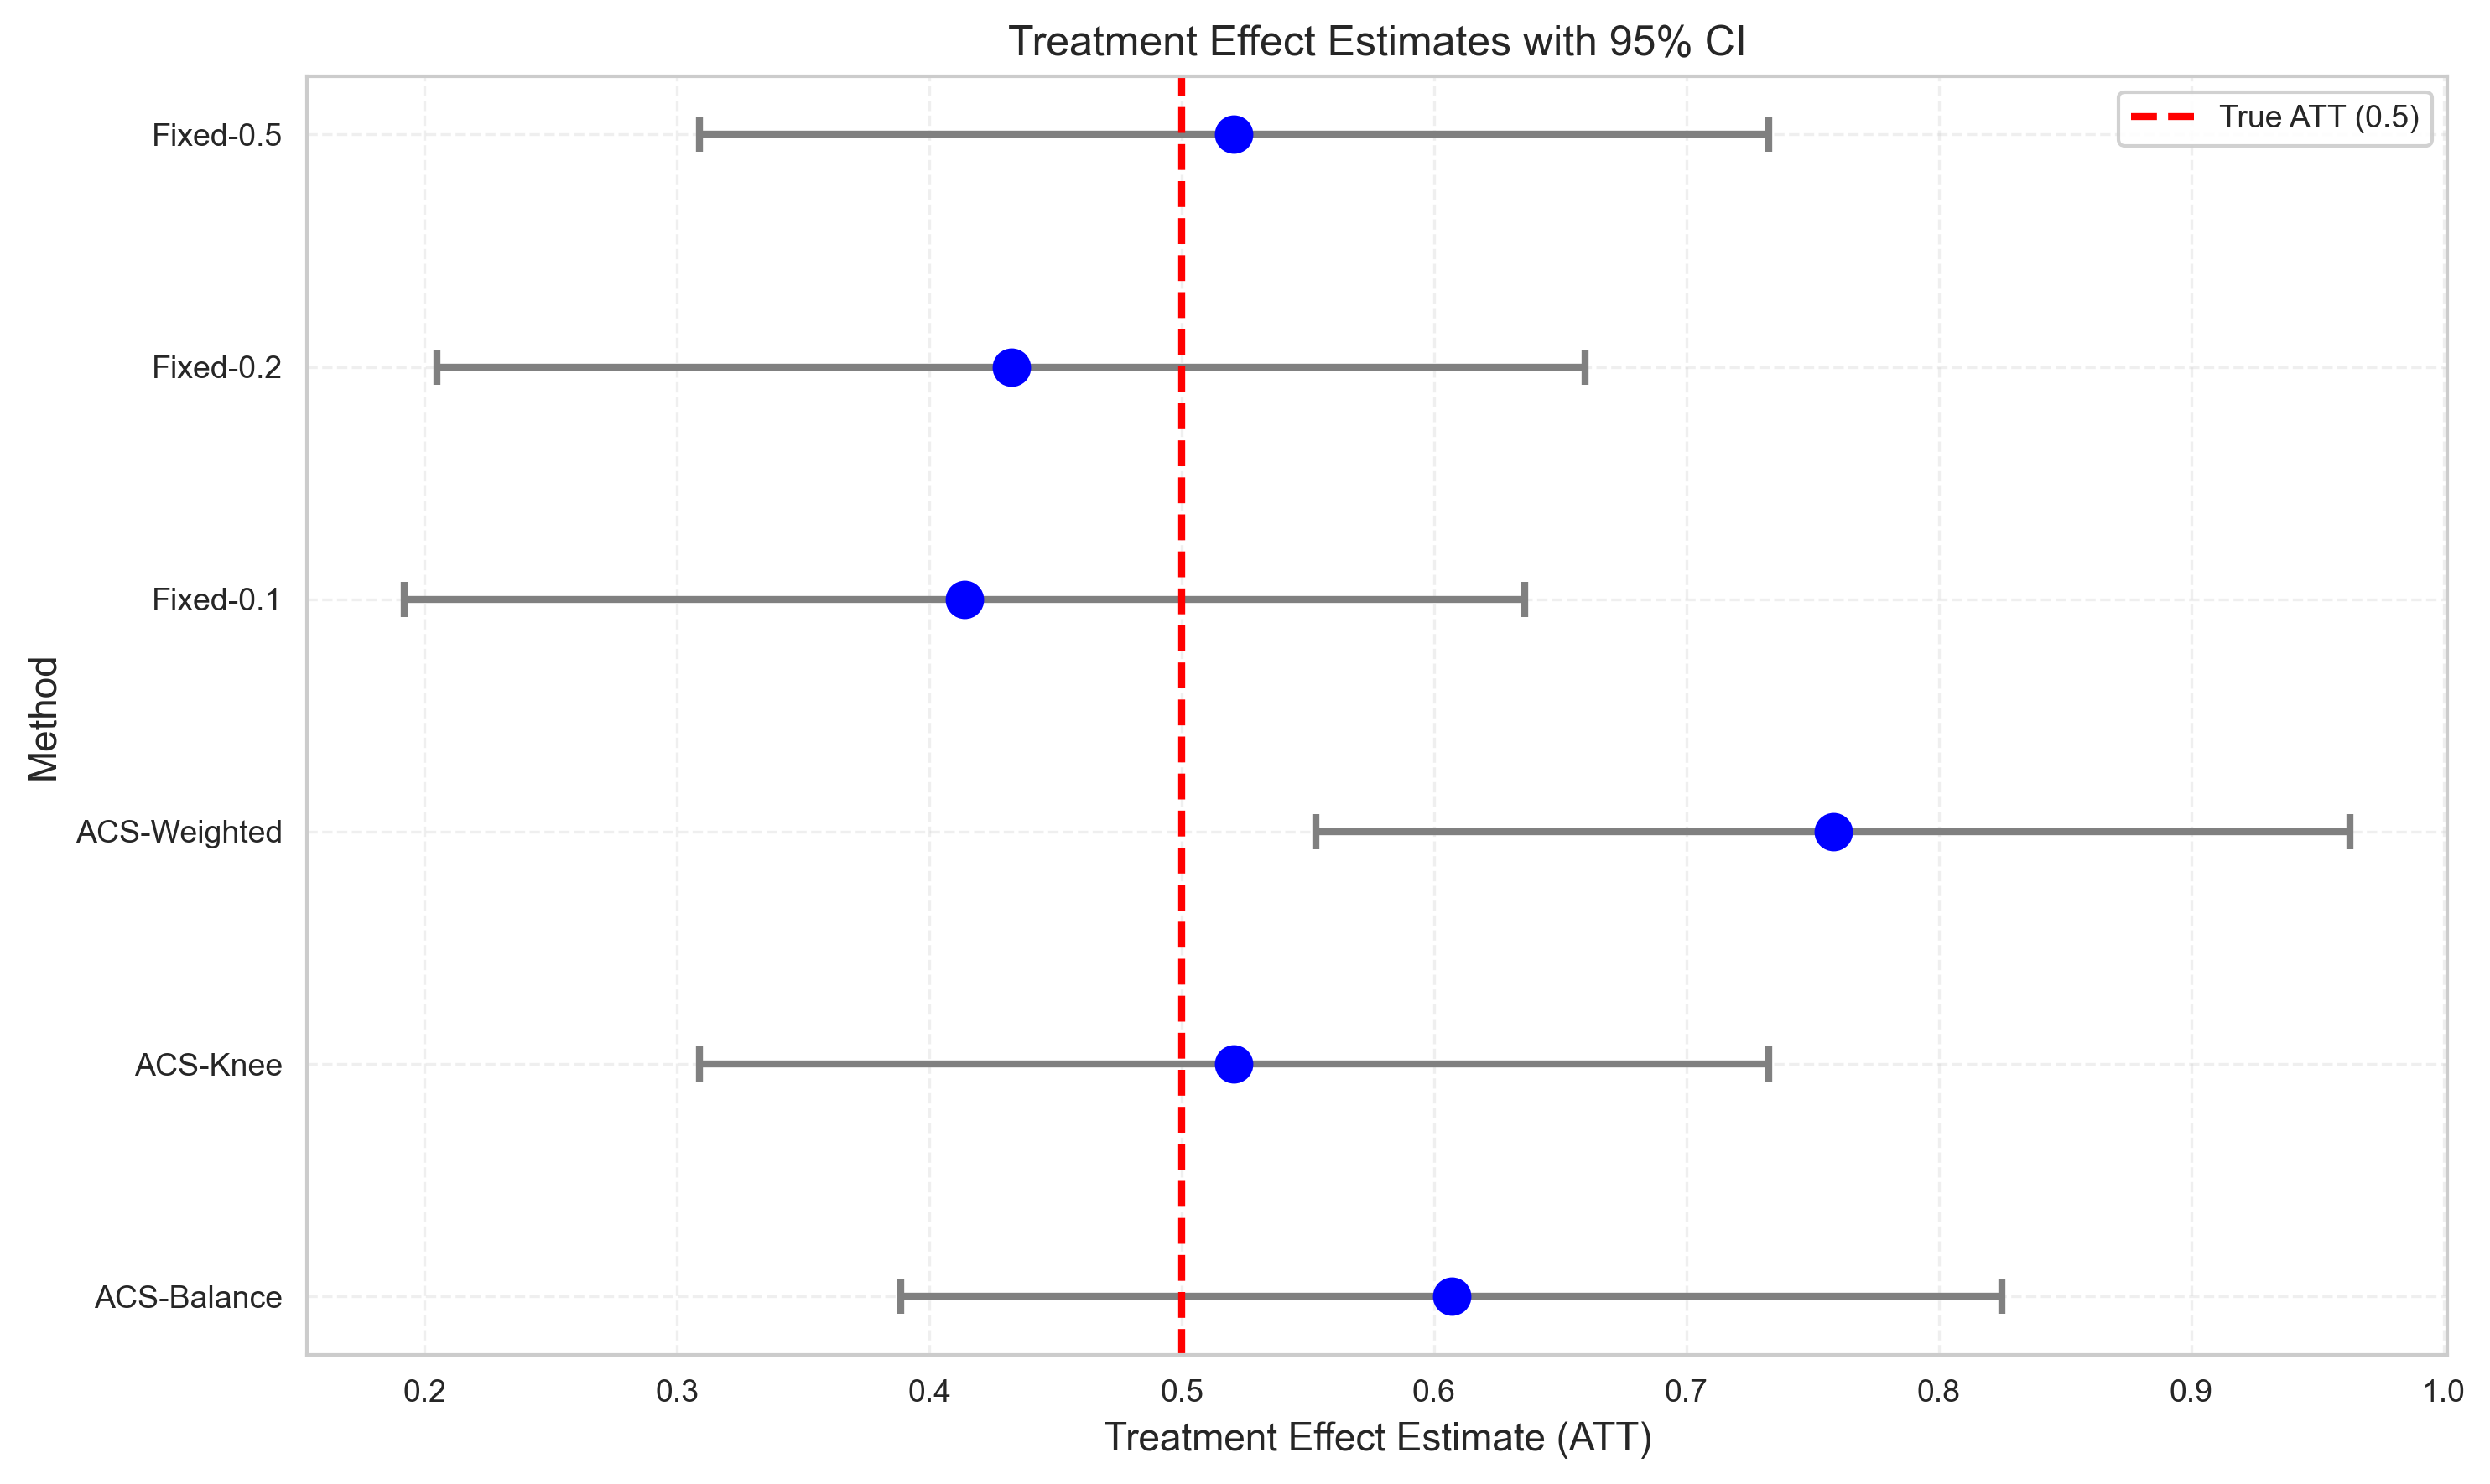

In [12]:
# =============================================================================
# FIGURE 5: TREATMENT EFFECT ESTIMATES
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

methods = te_df['Method'].values
y_pos = np.arange(len(methods))
estimates = te_df['Estimated ATT'].values
ci_lower = te_df['95% CI Lower'].values
ci_upper = te_df['95% CI Upper'].values

errors = np.array([estimates - ci_lower, ci_upper - estimates])

ax.errorbar(estimates, y_pos, xerr=errors, fmt='o', capsize=5, capthick=2, 
            markersize=10, color='blue', ecolor='gray', elinewidth=2)

ax.axvline(TRUE_TREATMENT_EFFECT, color='red', linestyle='--', linewidth=2, 
           label=f'True ATT ({TRUE_TREATMENT_EFFECT})')

ax.set_yticks(y_pos)
ax.set_yticklabels(methods)
ax.set_xlabel('Treatment Effect Estimate (ATT)', fontsize=11)
ax.set_ylabel('Method', fontsize=11)
ax.set_title('Treatment Effect Estimates with 95% CI', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig5_treatment_effect_estimates.png', dpi=FIGURE_DPI, bbox_inches='tight')
print(f'Saved: {FIGURES_DIR / "fig5_treatment_effect_estimates.png"}')
plt.show()

---
## Section 8: Monte Carlo Simulation

In [13]:
# =============================================================================
# SECTION 8: MONTE CARLO SIMULATION
# =============================================================================

scenario = {
    'scenario_id': 1,
    'n': 1000,
    'treatment_prevalence': 0.5,
    'overlap_name': 'medium',
    'overlap_level': 0.6,
    'confounding_name': 'strong',
    'confounding_strength': 1.0
}

N_REPS = 100

print('=' * 70)
print('MONTE CARLO SIMULATION')
print('=' * 70)
print(f'Scenario: n={scenario["n"]}, overlap={scenario["overlap_name"]}')
print(f'Replications: {N_REPS}')
print('Running simulation...')

mc_results = run_scenario_simulation(scenario, n_replications=N_REPS, n_jobs=1, verbose=True)
print('Simulation complete!')

MONTE CARLO SIMULATION
Scenario: n=1000, overlap=medium
Replications: 100
Running simulation...

Running scenario 1: 


100%|██████████| 100/100 [00:32<00:00,  3.10it/s]

Simulation complete!


In [14]:
# =============================================================================
# TABLE 6: MONTE CARLO SUMMARY
# =============================================================================

method_order = ['Fixed-0.1', 'Fixed-0.2', 'Fixed-0.5', 'No Caliper', 
                'ACS-Balance', 'ACS-Knee', 'ACS-Weighted']

available_methods = [m for m in method_order if m in mc_results['method'].unique()]

mc_summary = mc_results.groupby('method').agg({
    'n_matched': ['mean', 'std'],
    'retention': ['mean', 'std'],
    'max_smd': ['mean', 'std'],
    'bias': ['mean', lambda x: np.mean(np.abs(x)), 'std'],
    'mse': 'mean',
    'coverage': 'mean'
}).round(4)

mc_summary.columns = ['N_mean', 'N_sd', 'Ret_mean', 'Ret_sd', 
                      'SMD_mean', 'SMD_sd', 'Bias_mean', 'AbsBias', 'Bias_sd', 
                      'MSE', 'Coverage']
mc_summary = mc_summary.reindex(available_methods)

print('=' * 100)
print('TABLE 6: MONTE CARLO RESULTS')
print('=' * 100)
print(f'Replications: {N_REPS}, True ATT: {TRUE_TREATMENT_EFFECT}\n')
print(mc_summary.to_string())

mc_summary.to_csv(TABLES_DIR / 'table6_monte_carlo_summary.csv')
mc_results.to_csv(RESULTS_DIR / 'monte_carlo_raw_results.csv', index=False)
print(f'\nSaved: {TABLES_DIR / "table6_monte_carlo_summary.csv"}')

TABLE 6: MONTE CARLO RESULTS
Replications: 100, True ATT: 0.5

              N_mean     N_sd  Ret_mean  Ret_sd  SMD_mean  SMD_sd  Bias_mean  AbsBias  Bias_sd     MSE  Coverage
method                                                                                                          
Fixed-0.1     299.67  13.7209    0.6136  0.0318    0.0625  0.0242    -0.0024   0.0702   0.0892  0.0190      0.99
Fixed-0.2     303.76  13.3471    0.6220  0.0311    0.0624  0.0225     0.0111   0.0679   0.0883  0.0188      0.98
Fixed-0.5     321.48  12.1626    0.6583  0.0292    0.0777  0.0213     0.0964   0.1124   0.0867  0.0272      0.89
No Caliper    488.56   8.7355    1.0000  0.0000    0.5177  0.0576     1.3412   1.3412   0.1497  1.8322      0.00
ACS-Balance   332.18  19.9881    0.6802  0.0445    0.0903  0.0086     0.1542   0.1608   0.0991  0.0438      0.65
ACS-Knee      325.07  19.0789    0.6656  0.0416    0.0797  0.0328     0.1158   0.1332   0.1242  0.0391      0.74
ACS-Weighted  362.21  26.6872    

Saved: C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\figures\fig6_monte_carlo_results.png


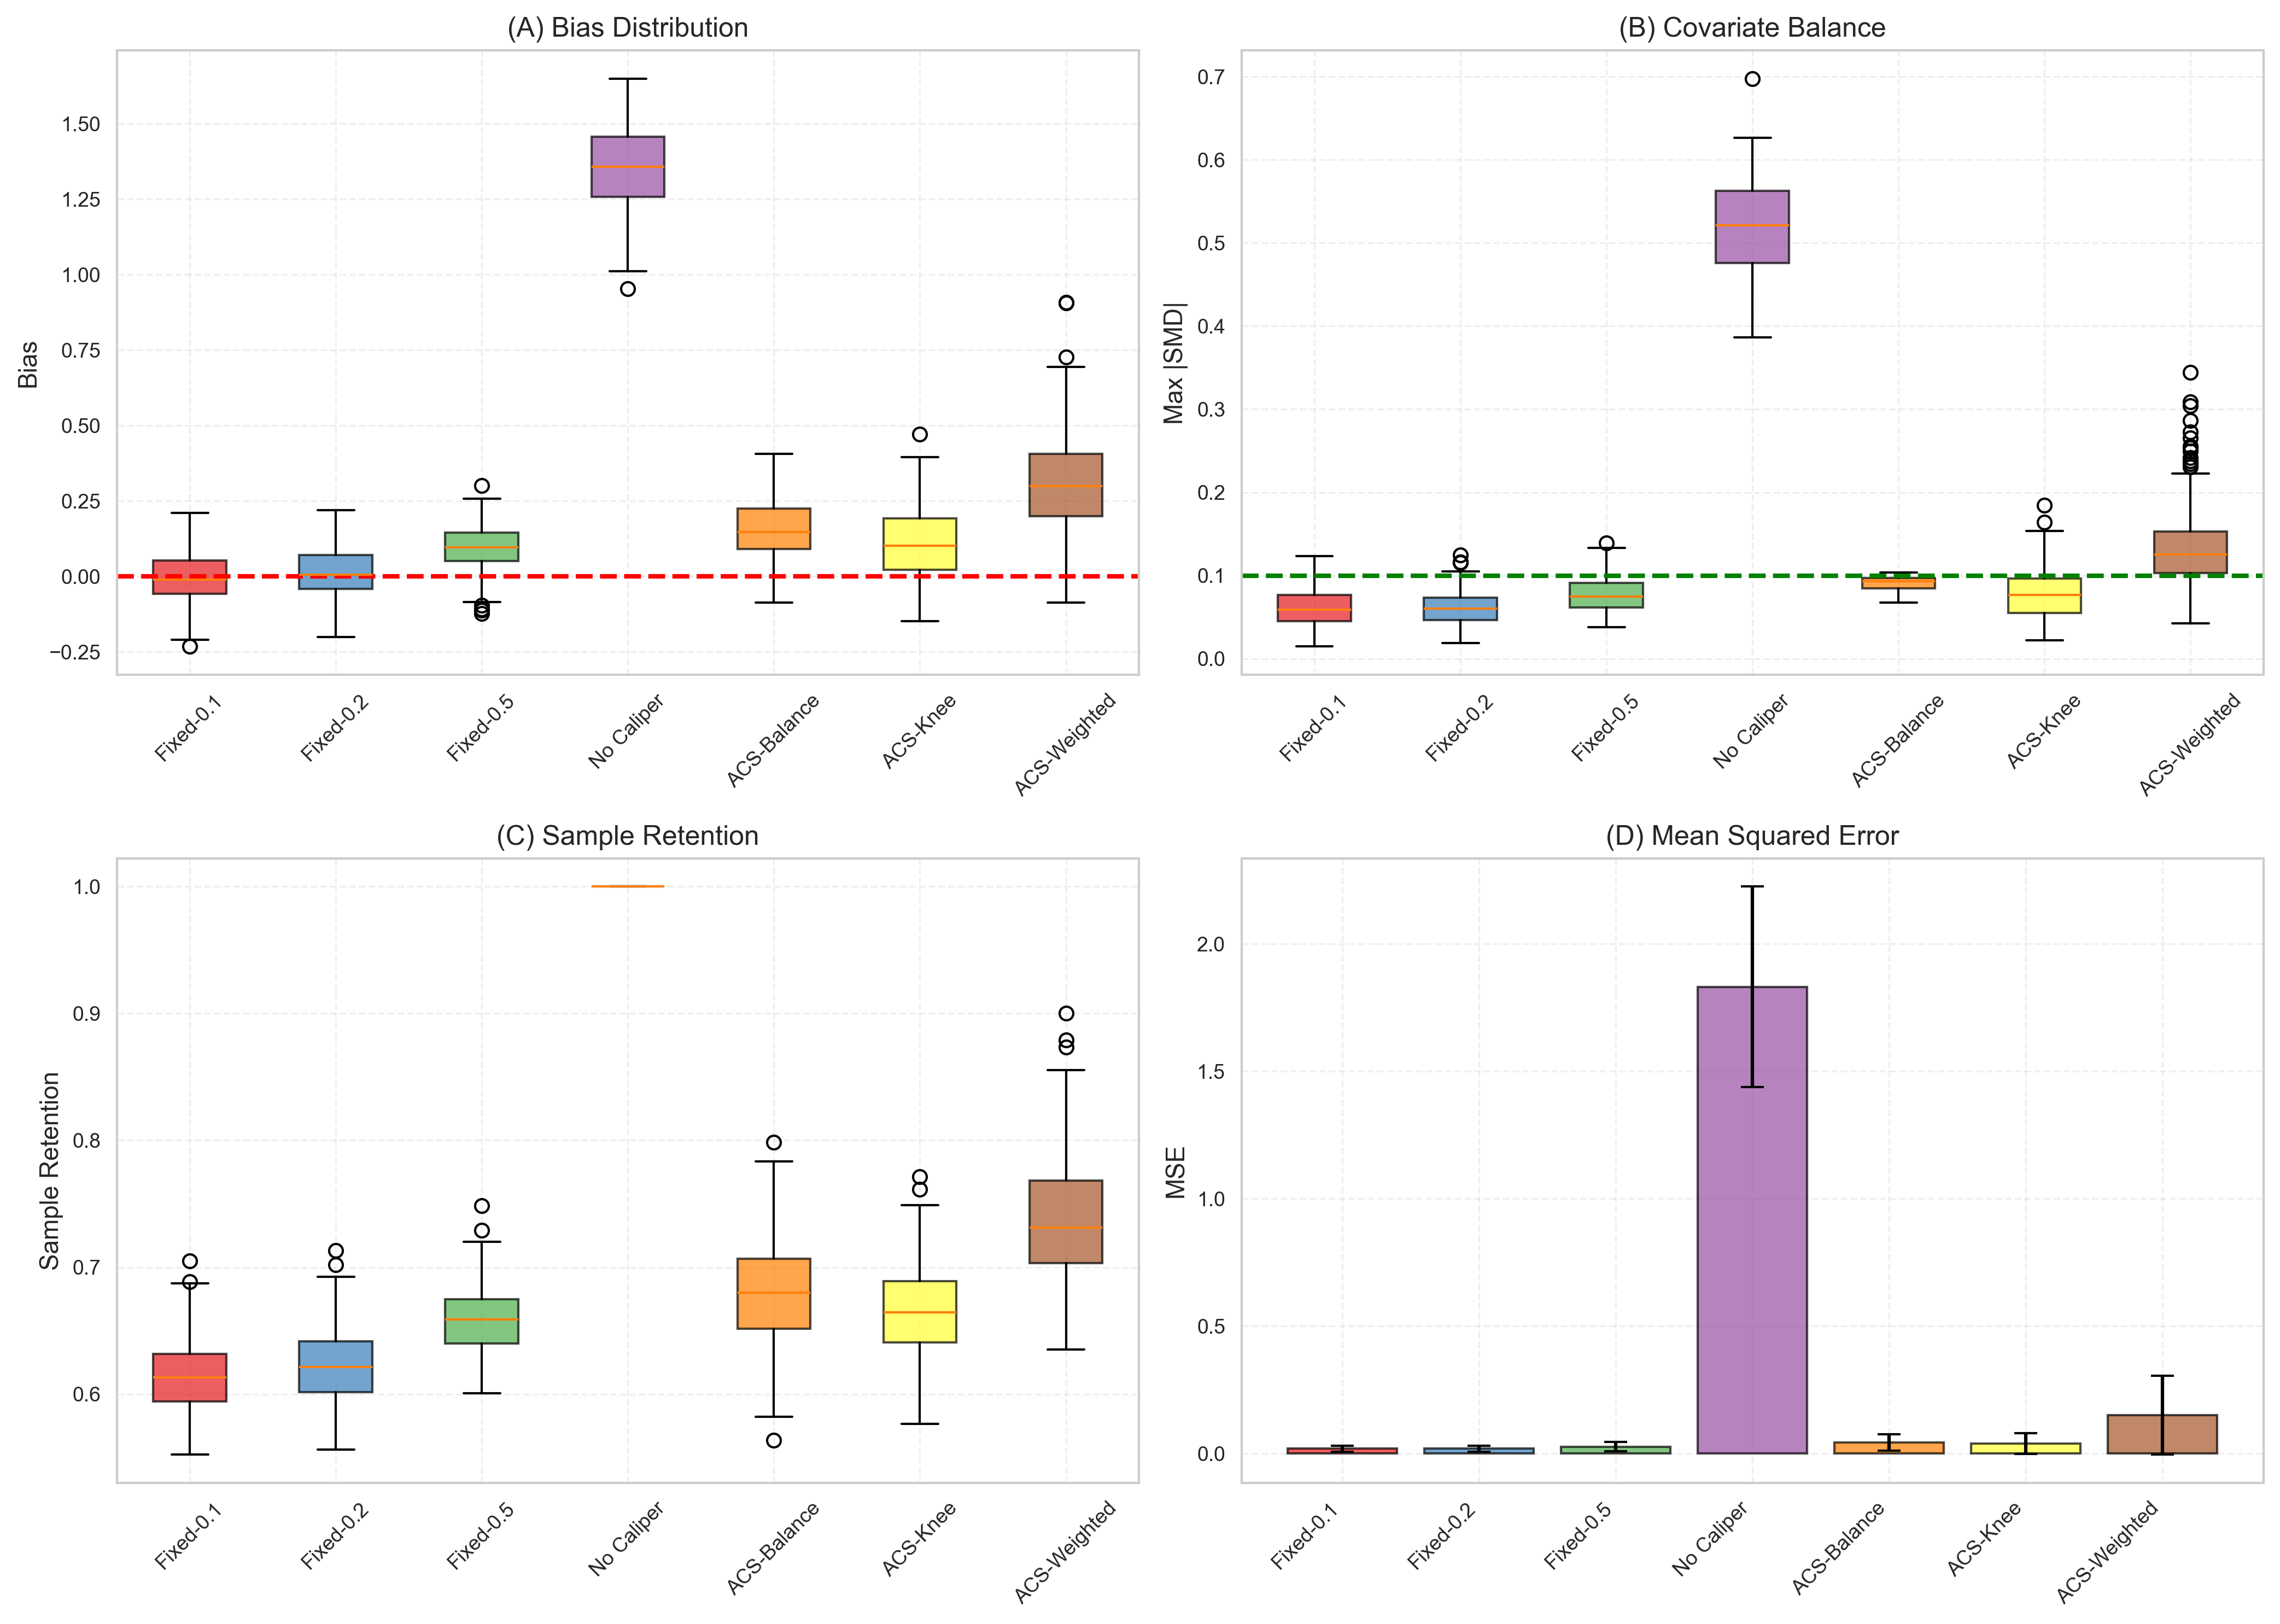

In [15]:
# =============================================================================
# FIGURE 6: MONTE CARLO RESULTS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
bias_data = [mc_results[mc_results['method']==m]['bias'].dropna() for m in available_methods]
bp1 = ax1.boxplot(bias_data, labels=available_methods, patch_artist=True)
for patch, method in zip(bp1['boxes'], available_methods):
    patch.set_facecolor(METHOD_COLORS.get(method, 'gray'))
    patch.set_alpha(0.7)
ax1.axhline(0, color='red', linestyle='--', linewidth=2)
ax1.set_ylabel('Bias', fontsize=11)
ax1.set_title('(A) Bias Distribution', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

ax2 = axes[0, 1]
smd_data = [mc_results[mc_results['method']==m]['max_smd'].dropna() for m in available_methods]
bp2 = ax2.boxplot(smd_data, labels=available_methods, patch_artist=True)
for patch, method in zip(bp2['boxes'], available_methods):
    patch.set_facecolor(METHOD_COLORS.get(method, 'gray'))
    patch.set_alpha(0.7)
ax2.axhline(BALANCE_THRESHOLD, color='green', linestyle='--', linewidth=2)
ax2.set_ylabel('Max |SMD|', fontsize=11)
ax2.set_title('(B) Covariate Balance', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

ax3 = axes[1, 0]
ret_data = [mc_results[mc_results['method']==m]['retention'].dropna() for m in available_methods]
bp3 = ax3.boxplot(ret_data, labels=available_methods, patch_artist=True)
for patch, method in zip(bp3['boxes'], available_methods):
    patch.set_facecolor(METHOD_COLORS.get(method, 'gray'))
    patch.set_alpha(0.7)
ax3.set_ylabel('Sample Retention', fontsize=11)
ax3.set_title('(C) Sample Retention', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

ax4 = axes[1, 1]
mse_means = [mc_results[mc_results['method']==m]['mse'].mean() for m in available_methods]
mse_stds = [mc_results[mc_results['method']==m]['mse'].std() for m in available_methods]
ax4.bar(range(len(available_methods)), mse_means, yerr=mse_stds, capsize=5,
        color=[METHOD_COLORS.get(m, 'gray') for m in available_methods], alpha=0.7,
        edgecolor='black', linewidth=1)
ax4.set_xticks(range(len(available_methods)))
ax4.set_xticklabels(available_methods, rotation=45, ha='right')
ax4.set_ylabel('MSE', fontsize=11)
ax4.set_title('(D) Mean Squared Error', fontsize=12)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_monte_carlo_results.png', dpi=FIGURE_DPI, bbox_inches='tight')
print(f'Saved: {FIGURES_DIR / "fig6_monte_carlo_results.png"}')
plt.show()

Saved: C:\Users\perkins.watambwa\Music\Adaptive-Caliper-in-Propensity-Score-Matching\outputs\figures\fig7_mc_tradeoff.png


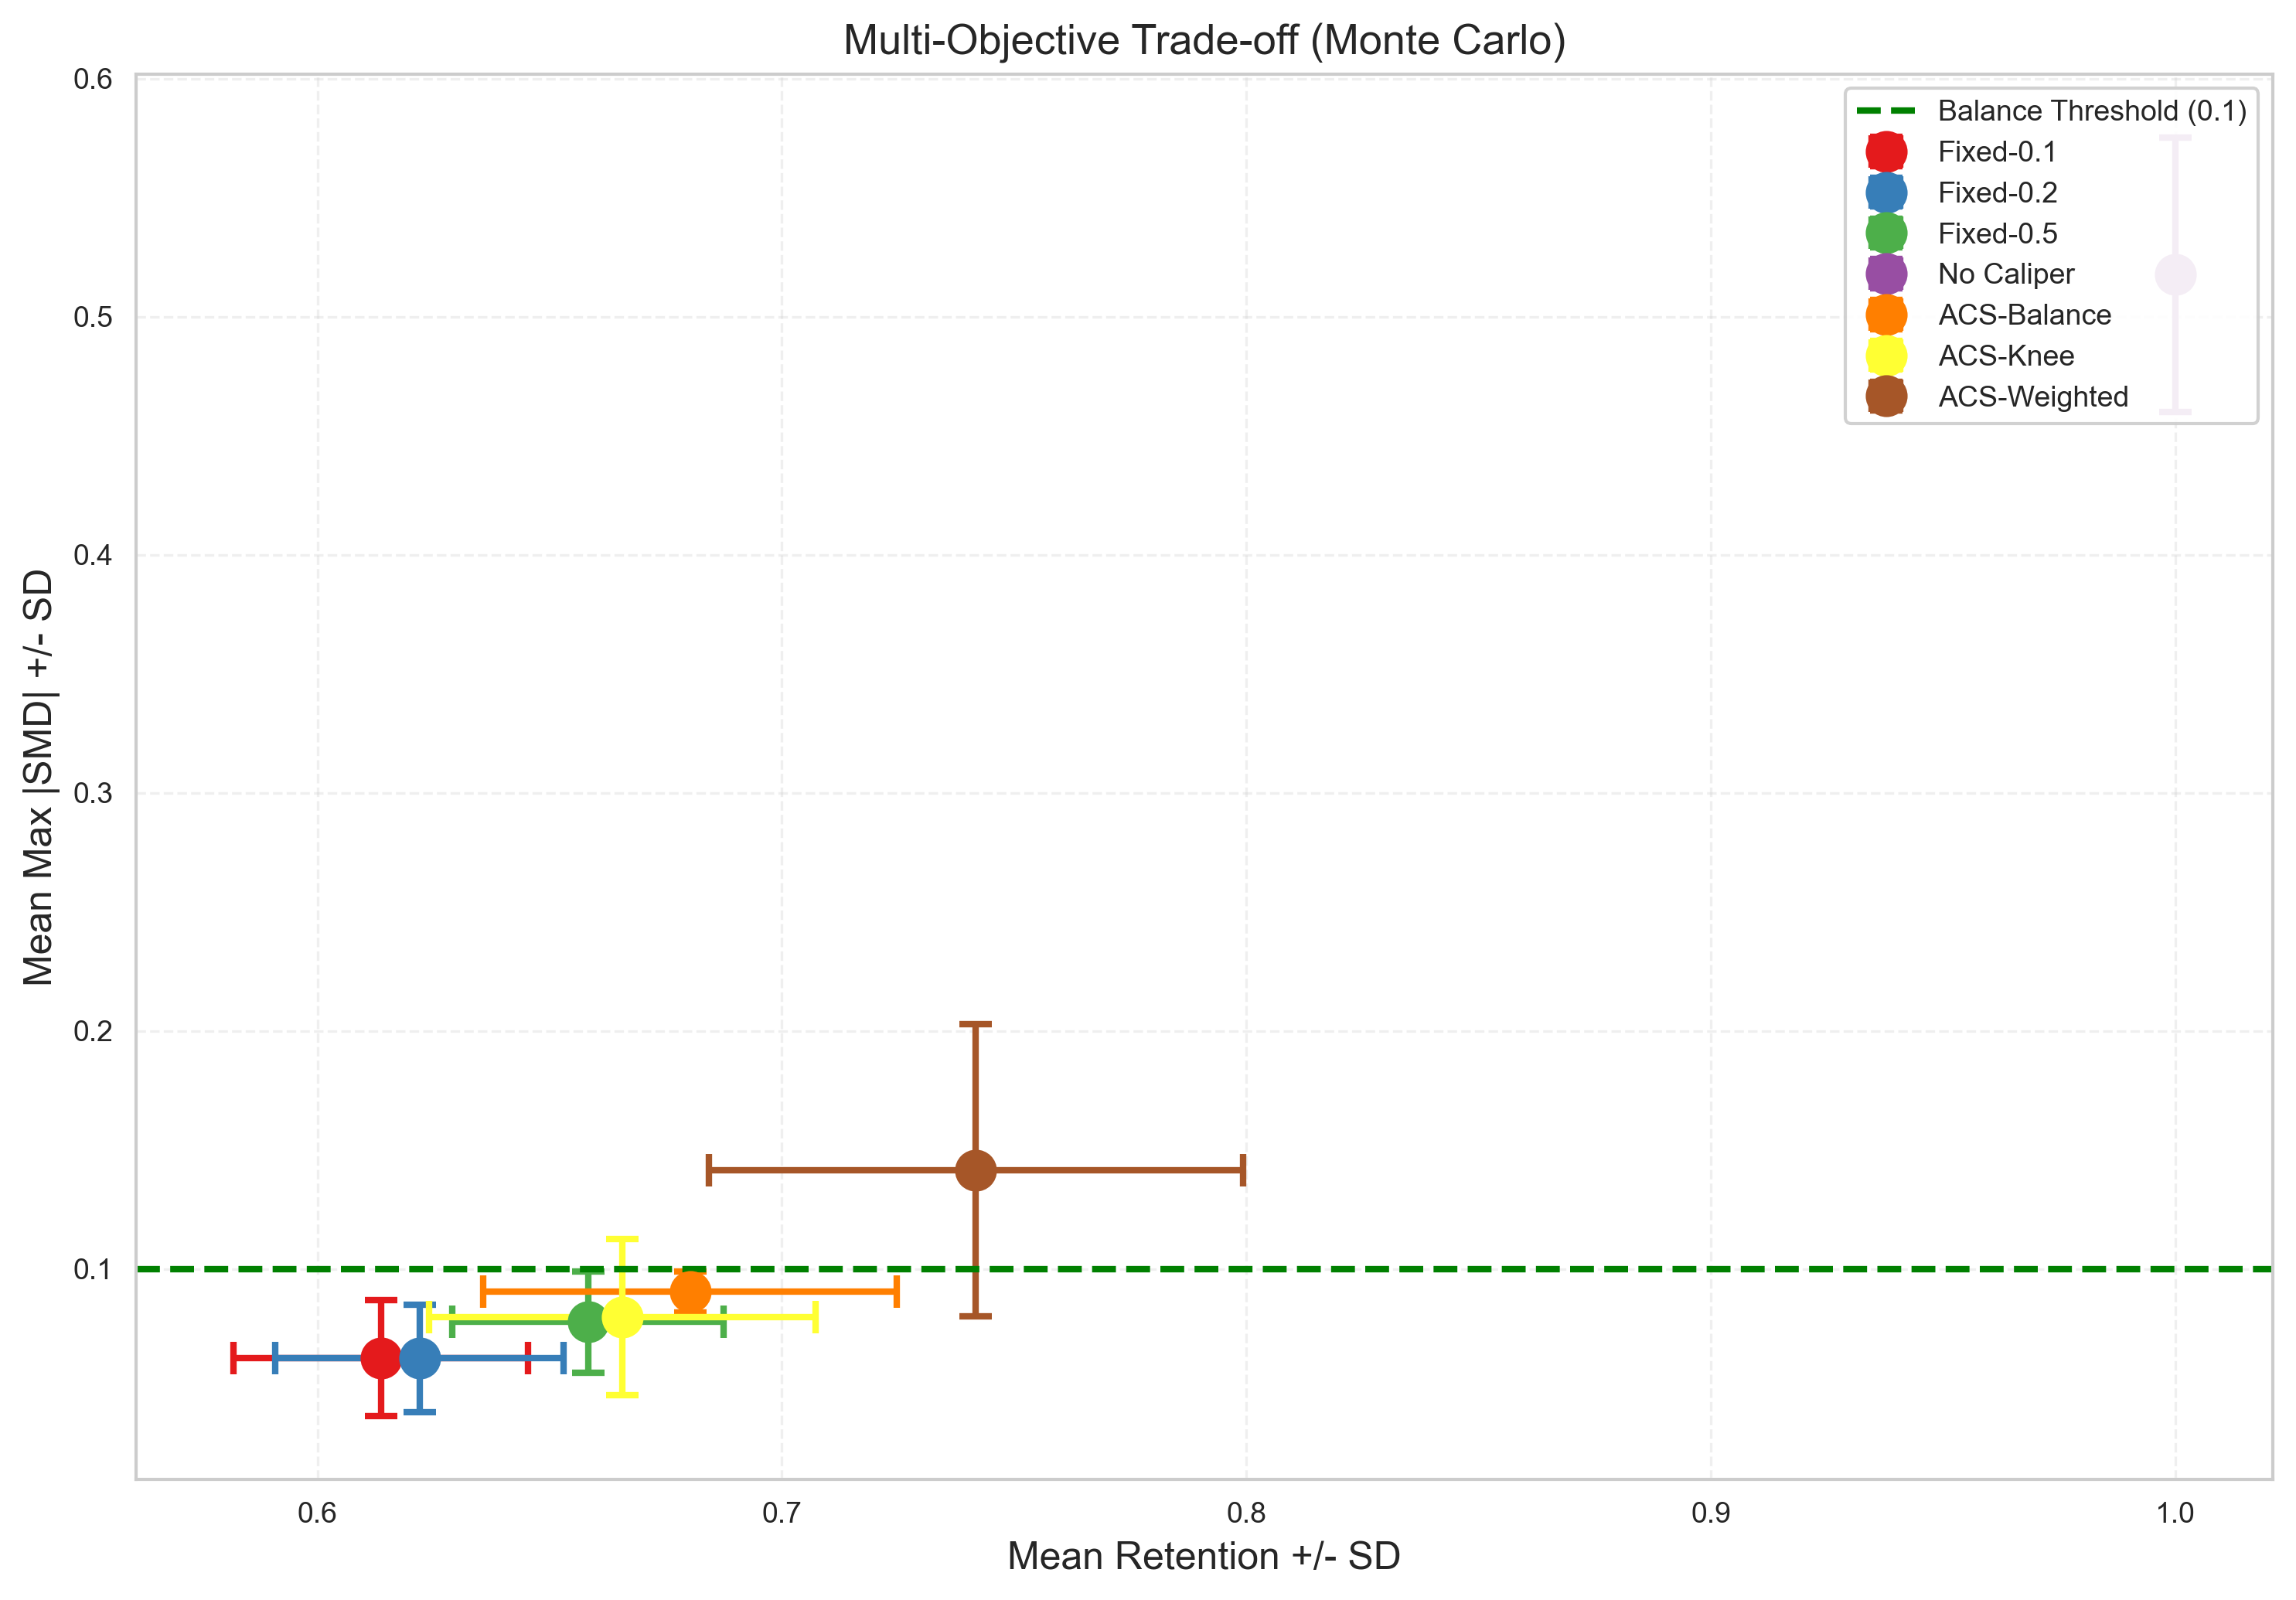

In [16]:
# =============================================================================
# FIGURE 7: MULTI-OBJECTIVE TRADE-OFF
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 7))

for method in available_methods:
    method_data = mc_results[mc_results['method'] == method]
    mean_ret = method_data['retention'].mean()
    mean_smd = method_data['max_smd'].mean()
    std_ret = method_data['retention'].std()
    std_smd = method_data['max_smd'].std()
    
    ax.errorbar(mean_ret, mean_smd, xerr=std_ret, yerr=std_smd,
                fmt='o', markersize=12, capsize=5, capthick=2,
                color=METHOD_COLORS.get(method, 'gray'),
                label=method, elinewidth=2)

ax.axhline(BALANCE_THRESHOLD, color='green', linestyle='--', linewidth=2, 
           label=f'Balance Threshold ({BALANCE_THRESHOLD})')

ax.set_xlabel('Mean Retention +/- SD', fontsize=12)
ax.set_ylabel('Mean Max |SMD| +/- SD', fontsize=12)
ax.set_title('Multi-Objective Trade-off (Monte Carlo)', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig7_mc_tradeoff.png', dpi=FIGURE_DPI, bbox_inches='tight')
print(f'Saved: {FIGURES_DIR / "fig7_mc_tradeoff.png"}')
plt.show()

---
## Section 9: Summary

In [17]:
# =============================================================================
# SECTION 9: FINAL SUMMARY
# =============================================================================

print('=' * 80)
print('SIMULATION STUDY: FINAL SUMMARY')
print('=' * 80)

print('\n### Key Findings ###\n')

best_bias = mc_summary['AbsBias'].idxmin()
best_balance = mc_summary['SMD_mean'].idxmin()
best_retention = mc_summary['Ret_mean'].idxmax()
best_mse = mc_summary['MSE'].idxmin()
best_coverage = mc_summary['Coverage'].idxmax()

print(f'Best Absolute Bias:    {best_bias} ({mc_summary.loc[best_bias, "AbsBias"]:.4f})')
print(f'Best Balance (SMD):    {best_balance} ({mc_summary.loc[best_balance, "SMD_mean"]:.4f})')
print(f'Best Retention:        {best_retention} ({mc_summary.loc[best_retention, "Ret_mean"]:.2%})')
print(f'Best MSE:              {best_mse} ({mc_summary.loc[best_mse, "MSE"]:.4f})')
print(f'Best Coverage:         {best_coverage} ({mc_summary.loc[best_coverage, "Coverage"]:.2%})')

print('\n### Output Files ###\n')
print('FIGURES:')
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(f'  - {f.name}')

print('\nTABLES:')
for f in sorted(TABLES_DIR.glob('*.csv')):
    print(f'  - {f.name}')

print('\n' + '=' * 80)
print('SIMULATION COMPLETE!')
print('=' * 80)

SIMULATION STUDY: FINAL SUMMARY

### Key Findings ###

Best Absolute Bias:    Fixed-0.2 (0.0679)
Best Balance (SMD):    Fixed-0.2 (0.0624)
Best Retention:        No Caliper (100.00%)
Best MSE:              Fixed-0.2 (0.0188)
Best Coverage:         Fixed-0.1 (99.00%)

### Output Files ###

FIGURES:
  - fig1_ps_distribution.png
  - fig2_pareto_frontier.png
  - fig3_optimal_caliper_selection.png
  - fig4_love_plot.png
  - fig5_treatment_effect_estimates.png
  - fig6_monte_carlo_results.png
  - fig7_mc_tradeoff.png

TABLES:
  - table1_all_caliper_evaluations.csv
  - table2_pareto_frontier.csv
  - table3_optimal_calipers_by_criterion.csv
  - table4_balance_comparison.csv
  - table5_treatment_effect_comparison.csv
  - table6_monte_carlo_summary.csv

SIMULATION COMPLETE!
